## Lab4: Generating CDFs

**Pick four simulations to complete. You do not have to do all of them.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(20260717)

In [2]:
# Helper functions


def ecdf_xy(samples):
    x = np.sort(np.asarray(samples))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


def plot_ecdf_vs_cdf(
    samples,
    cdf,
    grid=None,
    title="",
    xlabel="",
    discrete=False,
    logx=False
):
    x, y = ecdf_xy(samples)

    fig, ax = plt.subplots()

    ax.step(
        x,
        y,
        where="post",
        lw=2,
        label="simulation ECDF"
    )

    if grid is None:
        lo, hi = np.quantile(x, [0.001, 0.999])
        grid = np.linspace(lo, hi, 400)

    if discrete:
        ax.step(
            grid,
            cdf(grid),
            where="post",
            lw=2,
            label="scipy CDF"
        )
    else:
        ax.plot(
            grid,
            cdf(grid),
            lw=2,
            label="scipy CDF"
        )

    if logx:
        ax.set_xscale("log")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("cumulative probability")
    ax.legend()

    return ax


def show_quantiles(
    samples,
    dist,
    probs=(0.1, 0.25, 0.5, 0.75, 0.9)
):
    return pd.DataFrame({
        "p": probs,
        "simulation": np.quantile(samples, probs),
        "scipy": dist.ppf(probs),
    })

### Q1. OK, a warm-up, just to get started.
1. Set up a grid of `K` equally spaced values between 0 and 1, {1/K, 2/K, ..., K/K}.
2. Draw a point from the grid at random with equal probability.
3. For a very small `K`, repeat the above process `n = 5_000` times, and plot the ECDF of the draws.
4. What distribution does this approach as you increase `K`

<Axes: title={'center': 'Q1: Grid simulation, K=5'}, xlabel='x', ylabel='cumulative probability'>

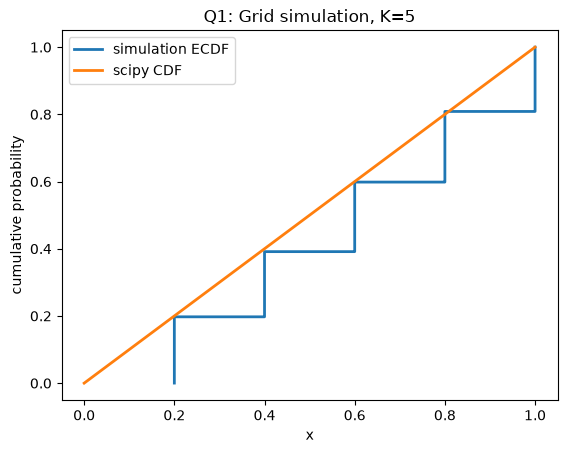

In [6]:
# Q1

K = 5
n = 5000

# equally spaced grid: 1/K, 2/K, ..., K/K
grid_values = np.arange(1, K + 1) / K

# randomly sample from the grid
samples = rng.choice(grid_values, size=n, replace=True)

# theoretical Uniform(0, 1) distribution
dist = stats.uniform(loc=0, scale=1)

# compare simulation ECDF with theoretical CDF
plot_ecdf_vs_cdf(
    samples,
    dist.cdf,
    grid=np.linspace(0, 1, 400),
    title=f"Q1: Grid simulation, K={K}",
    xlabel="x"
)

<Axes: title={'center': 'Q1: Grid simulation, K=100'}, xlabel='x', ylabel='cumulative probability'>

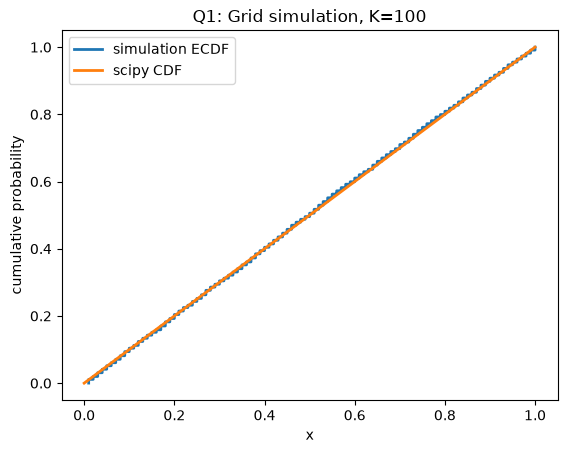

In [7]:
# Q1

K = 100
n = 5000

# equally spaced grid: 1/K, 2/K, ..., K/K
grid_values = np.arange(1, K + 1) / K

# randomly sample from the grid
samples = rng.choice(grid_values, size=n, replace=True)

# theoretical Uniform(0, 1) distribution
dist = stats.uniform(loc=0, scale=1)

# compare simulation ECDF with theoretical CDF
plot_ecdf_vs_cdf(
    samples,
    dist.cdf,
    grid=np.linspace(0, 1, 400),
    title=f"Q1: Grid simulation, K={K}",
    xlabel="x"
)

**As you can see in the graph above, as K increases the simiulated ECDF graph get closer to the theoritical unifrom(0,1) CDF. When K gets larger, the points gets closer and closer until we can't see the steps(steps gets sammler) and it almost hug the uniform distribution CDF. For example:**

When K= 5 grid= 0.2,0.4,0.6,0.8,1.0

and 

When K=100 grid= 0.01,0.02,0.03,…,1.00.

## Q2.
We often study sample averages: It's one of the first statistics you calculate for any dataset. What is the distribution of the sample mean?
1. Draw n = 32 values from `Uniform[-sqrt(3), sqrt(3)]`; these are your data. The choice of $+/- sqrt(3)$ ensures each draw has mean 0 and variance 1.
2. For this sample, compute the mean and multiply by np.sqrt(n).
3. Repeat the above process b = 5_000 times and plot the ECDF.
4. What distribution does this approach as  increases?

In [4]:
n = 32
b = 5000

sample_means = []

for _ in range(b):
    sample = rng.uniform(
        low=-np.sqrt(3),
        high=np.sqrt(3),
        size=n
    )

    sample_mean = np.mean(sample)

    standardized_mean = sample_mean * np.sqrt(n)

    sample_means.append(standardized_mean)

sample_means = np.array(sample_means)

<Axes: title={'center': 'Q2: Sampling distribution of the mean'}, xlabel='sqrt(n) * sample mean', ylabel='cumulative probability'>

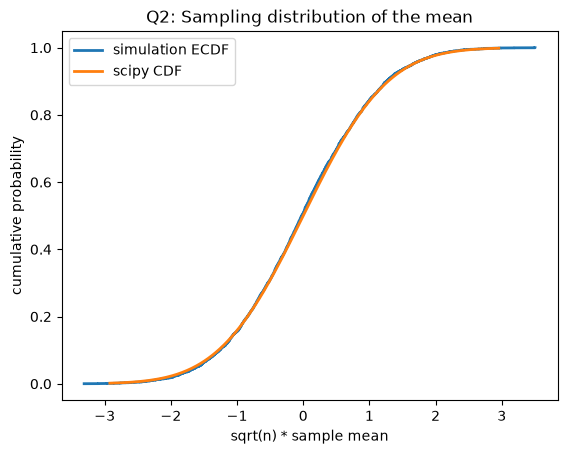

In [5]:
dist = stats.norm(loc=0, scale=1)

plot_ecdf_vs_cdf(
    sample_means,
    dist.cdf,
    title="Q2: Sampling distribution of the mean",
    xlabel="sqrt(n) * sample mean"
)

We learned that sample mean has sampling distribution. In this question we repeatedly gets sample from `unifrom (-sqrt(3),+sqrt(3))`, and find the mean of them, so, if wew repeat it many times, it forms a distribution. 

As you can see in the graph, both graphs almost got overlped or we can say that ECDF of simulated means follows closely the teoritical CDF. As It was asked ion the question, I drew `n=32` values in each sample from our uniform distribution `[-sqrt(3),+sqrt(3)]`, then calculated the mean of of each sample and multiplied it by `sqrt(n)`. I repeated this `b=5000` times    

The scaled sample mean

$$
\sqrt{n}\bar{X}
$$

it approaches a standard Normal distribution as `n` increases.

Therefore,

$$
\sqrt{n}\bar{X} \rightarrow N(0,1)
$$


## Q3:
In reliability engineering, we are often concerned with the proportions of failures that occur. For example, 
the Challenger space shuttle exploded on January 28, 1986, when the primary and secondary o-rings failed.
Floods often occur because too many levees or pumps are compromised. In this simulation, we have 40 units
that each fail with probability $p$, and we want to study the distribution of the survivors.
1. Flip `n = 40` coins, which each come up heads with probability $p = 1/2$ and tails with complementary probability.
2. From the final count of heads, subtract the expected number of heads, $n * p$.
3. Divide by the standard deviation $sqrt( n * p * (1-p) )$.
4. Repeat the above process `b = 5_000` times and plot the ECDF.
5. What distribution does this approach as `n` increases?
6. How do the results change as you adjust `p`?

In [ ]:
# simulation
# setup
n = 40 #flip
p = 0.5 #probability of head
b = 5000 #repeated 5000 times

z_val = []

for _ in range(b):
    heads = rng.binomial(n, p)

    z = (heads - n * p) / np.sqrt(n * p * (1 - p))

    z_val.append(z)

z_values = np.array(z_val)

<Axes: title={'center': 'Q3: Standardized Binomial'}, xlabel='standardized number of heads', ylabel='cumulative probability'>

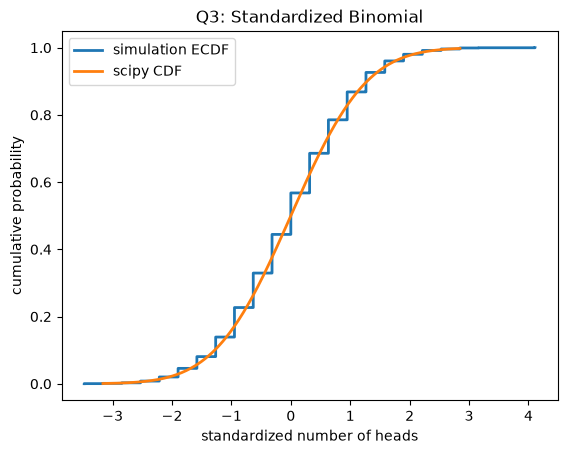

In [9]:
#comapre with standard Normal cdf
dist = stats.norm(loc=0, scale=1)

plot_ecdf_vs_cdf(
    z_val,
    dist.cdf,
    title="Q3: Standardized Binomial",
    xlabel="standardized number of heads"
)

<Axes: title={'center': 'Q3: Standardized Binomial'}, xlabel='standardized number of heads', ylabel='cumulative probability'>

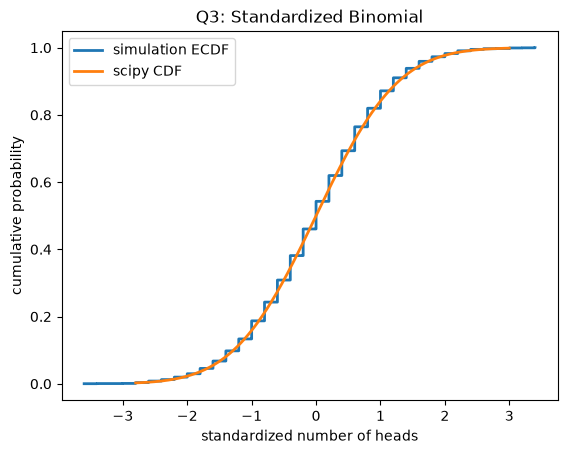

In [12]:
# simulation+ we increase n to 100
# setup
n = 100 # increase n to 100
p = 0.5 #probability of head
b = 5000 #repeated 5000 times

z_val = []

for _ in range(b):
    heads = rng.binomial(n, p)

    z = (heads - n * p) / np.sqrt(n * p * (1 - p))

    z_val.append(z)

z_values = np.array(z_val)

#comapre with standard Normal cdf
dist = stats.norm(loc=0, scale=1)

plot_ecdf_vs_cdf(
    z_val,
    dist.cdf,
    title="Q3: Standardized Binomial",
    xlabel="standardized number of heads"
)

**Bernoulli trials → Binomial count → standardize → approximately Normal**
In this simulation, we used the binomila distribution, sicne we are counting the numbe of `heads` from `n=40` independent coint flips. As it was mentioned in te question, the probabbility of Head is 0.5, so for each simulation, we count number of heads, and subtructed by $E[Head]=n*p$ , and then divided by standard deviation $sqrt(n * p * (1 - p))$

Standardize: $(heads - n * p) / np.sqrt(n * p * (1 - p))$

Repeated this 5000 times, as requested, and from the graph we cna notice that the `ECDF` of the standardized Binomial values is close to the theoretical standard Normal CDF.
So, as we increase n, teh values will get closer to the theoritical standard Normal CDF. 

As we adjust or change the $p$ the shape of Binomial distribution. For instance, as p gets closer to 0 the graph will be change to right skewed from symmetric and as p get closer the 1 shape of the graph change to left skewed. So, normal approximation with fixed n will be less acurate.

## Q4
A process is running in discrete time. In each time interval of length dt, it terminates with probability $r * dt$, where $r * dt < 1$. This is called an arrival, death, or survival process, and is popular for modeling how long patients live after a procedure, whether an employee quits, or the arrival of the next goal in a sportsball match.

1. For each simulation of the process, determine the period in which termination occurs.
2. Convert periods to time by multiplying by `dt`.
3. Repeat the simulation n = 5_000 times and plot the ECDF, for a value of `dt` close to zero (e.g. dt = 1e-3).
4. What distribution does this approach as `dt` goes to zero?
5. How do the results change as you adjust `r`?

**repeated small chances of termination → waiting time → Exponential distribution**
* r = 2
* dt = 0.001
* probability-> r * dt = 2(0.001) = 0.002

step 1   → survives

step 2   → survives

step 3   → survives

...

step 420 → terminates

the waiting time would be -> 420 × 0.001 = 0.42.

repeat 5000 times
* get 5000 waiting times
* build ECDF
* compare with Exponential CDF

In [22]:
r = 2  # suppose r=2
dt = 0.001  # length of each time interval
n = 5000  # repeat it 5000 times

times = []  # we store the termination time in a list

for _ in range(n):
    periods = 0  # start counting the time periods from 0

    while True:
        periods += 1  # move to the next time interval

        # generate a random number between 0 and 1
        # if it is less than or equal to r * dt, the process terminates
        if rng.random() <= r * dt:
            break  # stop the while loop when termination happens

    time = periods * dt  # convert number of periods to waiting time
    times.append(time)  # store the waiting time for this simulation

times = np.array(times)  # convert the list to a numpy array

<Axes: title={'center': 'Q4: Termination Time'}, xlabel='time', ylabel='cumulative probability'>

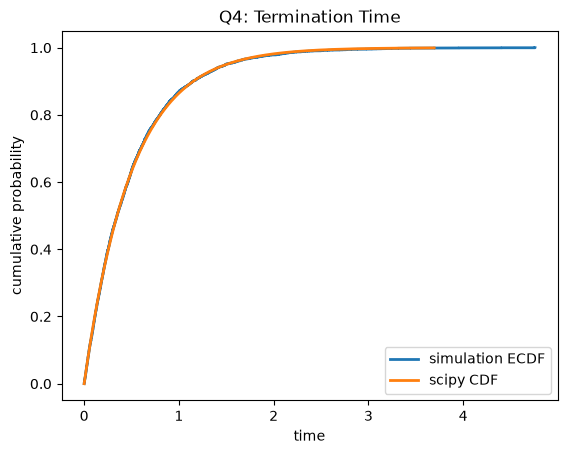

In [21]:
dist = stats.expon(scale=1 / r)

plot_ecdf_vs_cdf(
    times,
    dist.cdf,
    title="Q4: Termination Time",
    xlabel="time"
)

As you can see in the graph, the ECDF graph and CDF graph almost overlap, and the termination time approaches an exponential distribution. So, we can say that as dt goes to zero, the waiting times that we simulated approach an exponential distribution.

In the simulation, we have a probability of terminating in each small interval: $r * dt$

So, as dt becomes smaller (0.1, 0.01, 0.001, 0.0001....), our simulation will check more and more frequently, which means the interval becomes smaller and more precise. As a result, the simulated waiting time approaches the exponential distribution with our fixed r.

So,

$$
X \sim \text{Exponential}(r)
$$

and the theoretical CDF is

$$
F(x) = 1 - e^{-rx}.
$$

r is the termination rate, chnaging it will affect how quickly the termination happen. if r gets larger we have higher probability of termination in each time interval as result we will have shorter waiting time. In contrast,  if r gets smaller, we will have lower probability of termination in each time interval, and longer waiting time.   

As we leanred in the class, The mean waiting time is

$$
E[T] = \frac{1}{r}.
$$

For example, if `r = 2`, the mean waiting time is

$$
\frac{1}{2} = 0.5.
$$

### AI Citation 
I used ChatGPT to help debug portions of my Python code and to format mathematical expressions correctly in Markdown. I used the tool for troubleshooting and syntax support, while I wrote and interpreted the analysis myself.

OpenAI. (2026). ChatGPT (GPT-5.6 Sol) [Large language model]. https://chatgpt.com/